# Reproduce Classifier Results — LS8A (Formentera)

This notebook trains and evaluates the LightGBM benthic habitat classifier
on the processed per-site sample tables shipped in `data/`. It reproduces
the F1-Macro / Kappa / confusion-matrix results reported in the paper for
the LS8A (Formentera) Learning Site -- a 3-class drone-derived training
set (ANGIO / ROCK / SEDIMENT), with 130 spectral feature columns
(multi-temporal marine indices, t0-t3, plus their mean/std/range
aggregates).

**Not included**: the feature-extraction and drone-sample-extraction steps
that produced this table (raw Sentinel-2 -> ACOLITE correction -> spectral
feature extraction -> drone-raster resampling). Those are part of the
institute's internal pipeline. See the README for details.

The same notebook works unchanged on any other site's sample table -- just
point `SITE_FILE` at a different CSV.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

sys.path.insert(0, str(Path("..") / "src"))
from benthic_upscale import BenthicClassifier, BenthicMapper

DATA_DIR = Path("..") / "data"
RANDOM_SEED = 42

## 1. Load a processed sample table

Each CSV contains one row per pixel sample, with spectral feature columns
plus a `class` label and a `region` identifier. To try a different site,
point `SITE_FILE` at another per-site table (e.g. `ls3c_samples.csv`).

In [2]:
SITE_FILE = DATA_DIR / "ls8a_samples.csv"

samples = pd.read_csv(SITE_FILE)
non_feature_cols = {"class", "class_id", "region", "x_coord", "y_coord"}
feature_names = [c for c in samples.columns if c not in non_feature_cols]

print(f"Site        : {samples['region'].iloc[0]}")
print(f"Samples     : {len(samples):,}")
print(f"Features    : {len(feature_names)}")
print(f"Classes     : {sorted(samples['class'].unique())}")
samples.head()

Site        : ls8a
Samples     : 2,521
Features    : 131
Classes     : ['ANGIO', 'ROCK', 'SEDIMENT']


,Rrs_492_t0,Rrs_665_t0,Rrs_704_t0,Rrs_833_t0,NDVI_t0,NDWI_t0,BG_ratio_t0,GR_ratio_t0,NDAVI_t0,SAVI_t0,...,REP_std,REP_range,NR_ratio_mean,NR_ratio_std,NR_ratio_range,class_id,class,region,x_coord,y_coord
0,0.056877,0.089179,0.094667,0.108625,0.143403,-0.212457,0.735609,0.867023,-0.071224,-0.026689,...,0.010607,0.027520,1.264090,0.076661,0.159135,2,ANGIO,ls8a,5,0
1,0.060463,0.084229,0.090801,0.107704,0.140457,-0.177474,0.774499,0.926850,-0.037963,-0.013954,...,0.009892,0.024541,1.315872,0.051745,0.127395,2,ANGIO,ls8a,6,0
2,0.027259,0.023927,0.018217,0.014316,-0.307815,0.329094,1.086577,1.048503,0.023678,0.003171,...,0.010690,0.027699,0.566605,0.113873,0.289296,2,ANGIO,ls8a,16,0
3,0.014863,0.012545,0.008160,0.007264,-0.484123,0.556538,0.971091,1.220056,0.099122,0.007845,...,0.002401,0.006033,0.481492,0.144100,0.377114,2,ANGIO,ls8a,18,0
4,0.008967,0.003048,0.008160,0.003350,0.177098,0.296509,1.115845,2.636214,0.449978,0.014639,...,0.002401,0.006033,1.212935,0.330174,0.834292,2,ANGIO,ls8a,19,0


## 2. Train / validation / test split

80% train+val / 20% held-out test, stratified by class.
85% / 15% split of train+val for early-stopping validation.

In [3]:
X = samples[feature_names].values
y = samples["class"].values

X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.15, random_state=RANDOM_SEED, stratify=y_tv
)

print(f"Train : {len(X_train):,}")
print(f"Val   : {len(X_val):,}")
print(f"Test  : {len(X_test):,}")

Train : 1,713
Val   : 303
Test  : 505


## 3. Train the classifier

In [4]:
MODEL_PARAMS = {
    "n_estimators": 500,
    "max_depth": 15,
    "learning_rate": 0.05,
}

clf = BenthicClassifier(**MODEL_PARAMS)
clf.train(X_train, y_train, X_val, y_val, feature_names=feature_names)


Training LightGBM classifier ...
Training until validation scores don't improve for 50 rounds
[50]	train's multi_logloss: 0.145336	valid's multi_logloss: 0.414359
[100]	train's multi_logloss: 0.034138	valid's multi_logloss: 0.431129
Early stopping, best iteration is:
[63]	train's multi_logloss: 0.0995755	valid's multi_logloss: 0.404273
Training complete -- best iteration: 63


## 4. Evaluate on the held-out test set

In [5]:
results = clf.evaluate(X_test, y_test)

print("Test-set metrics")
print(f"  Accuracy      : {results['accuracy']:.4f}")
print(f"  F1-Macro      : {results['f1_macro']:.4f}")
print(f"  F1-Weighted   : {results['f1_weighted']:.4f}")
print(f"  Cohen's Kappa : {results['kappa']:.4f}")
print()
print(pd.DataFrame(results["classification_report"]).T)

Test-set metrics
  Accuracy      : 0.8337
  F1-Macro      : 0.8197
  F1-Weighted   : 0.8340
  Cohen's Kappa : 0.7313

              precision    recall  f1-score     support
ANGIO          0.881423  0.864341  0.872798  258.000000
ROCK           0.777027  0.815603  0.795848  141.000000
SEDIMENT       0.798077  0.783019  0.790476  106.000000
accuracy       0.833663  0.833663  0.833663    0.833663
macro avg      0.818842  0.820988  0.819707  505.000000
weighted avg   0.834780  0.833663  0.834034  505.000000


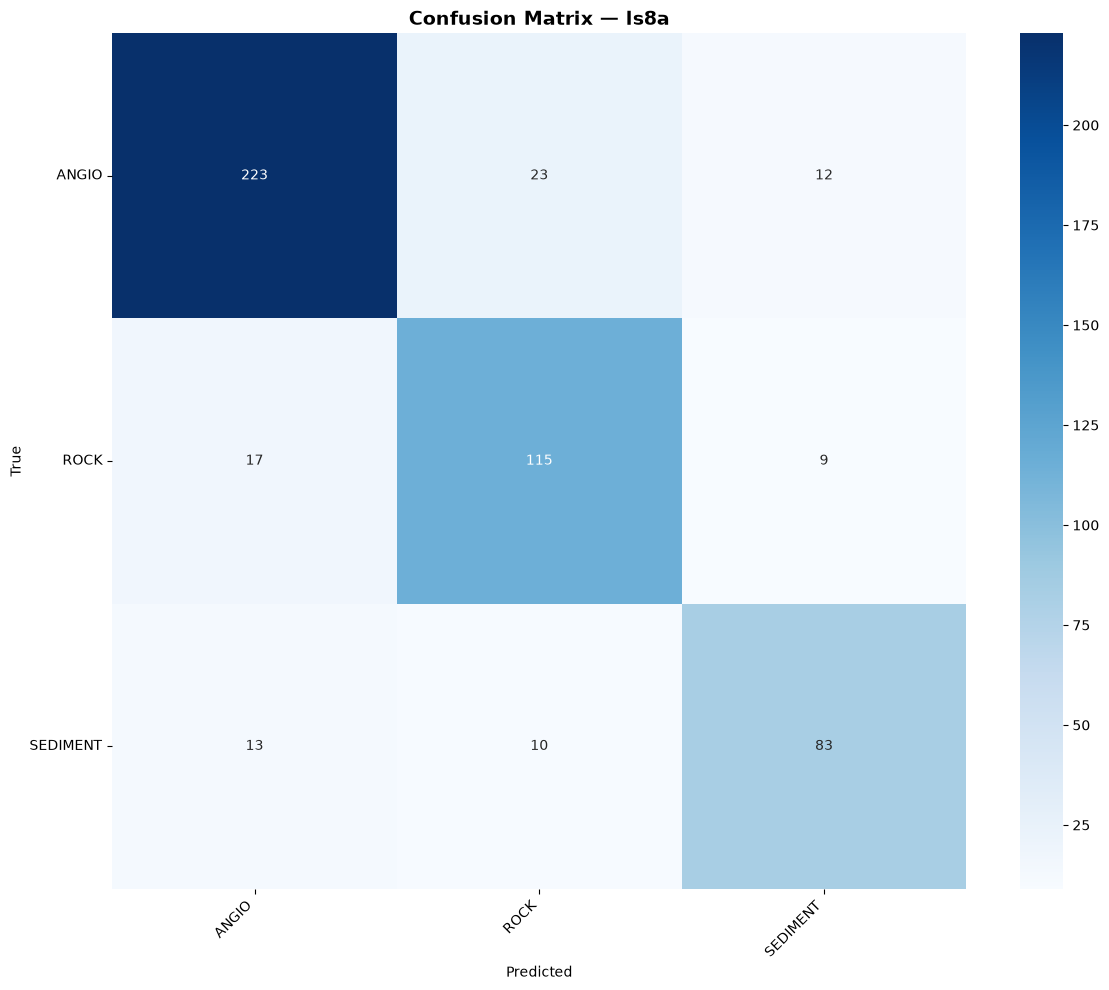

In [6]:
clf.plot_confusion_matrix(results, title=f"Confusion Matrix — {samples['region'].iloc[0]}")

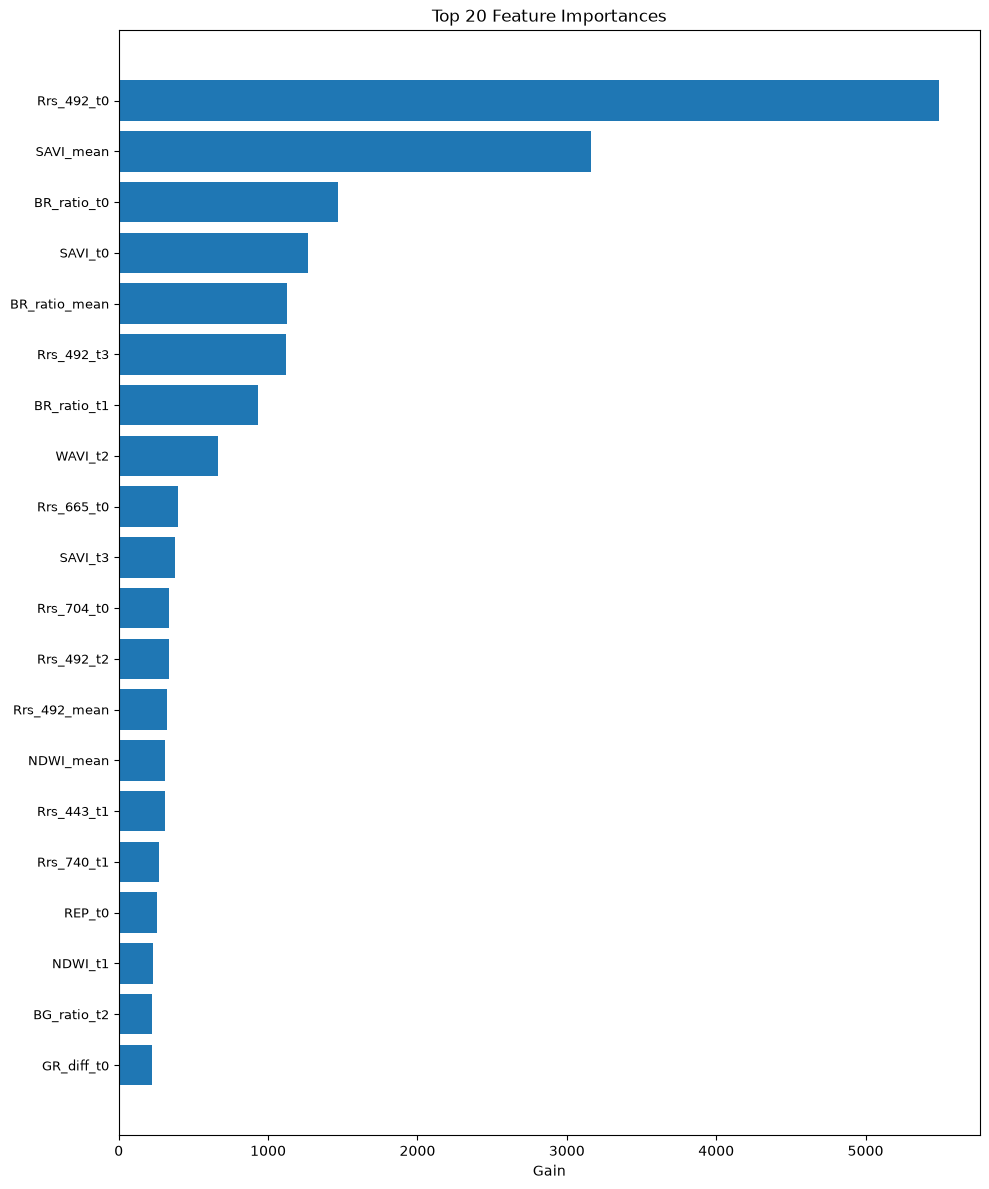

In [7]:
clf.plot_feature_importance(top_n=min(20, len(feature_names)))

## 5. (Optional) Full-stack prediction + habitat map

If you have a (H, W, F) feature stack for a full scene -- e.g. exported
from your own Sentinel-2 feature extraction, or provided as a `.npy` file
alongside the sample table -- you can reproduce the habitat map figure.
This step does not require raw imagery; it only needs an already-built
feature stack array.

No feature stack provided for this site — showing the pre-rendered full-scene map instead (produced by the institute's internal pipeline).


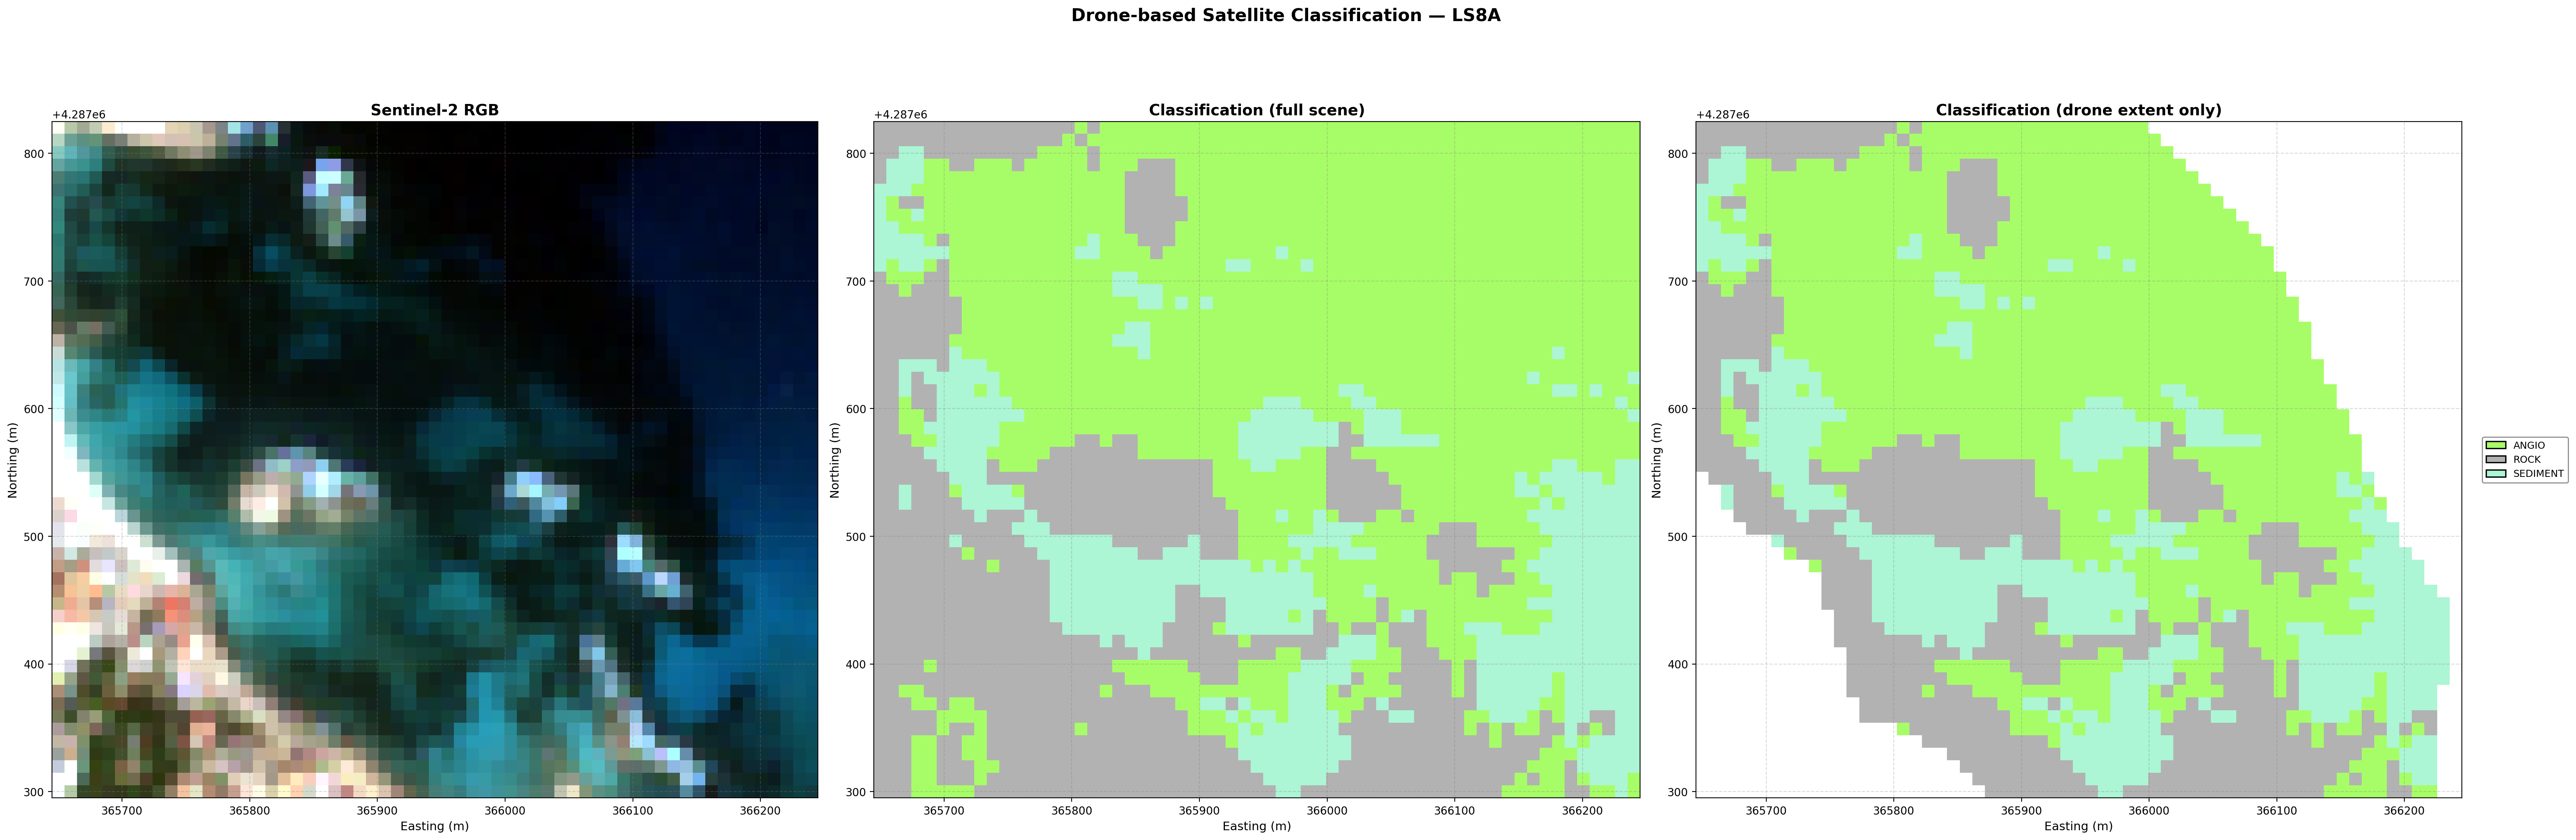

In [9]:
STACK_FILE = DATA_DIR / f"{samples['region'].iloc[0]}_feature_stack.npy"

if STACK_FILE.exists():
    feature_stack = np.load(STACK_FILE)
    mapper = BenthicMapper()

    pred_map = mapper.predict_full_image(feature_stack, clf, batch_size=50_000)
    mapper.plot_results(
        prediction_map=pred_map,
        classifier=clf,
        region=samples["region"].iloc[0],
    )
    areas = mapper.class_areas(pred_map, clf, pixel_size=10.0)
    print(areas.to_string(index=False))
else:
    region = samples["region"].iloc[0]
    map_png = DATA_DIR / f"map_{region}_drone.png"
    if map_png.exists():
        from IPython.display import Image, display
        print(f"No feature stack provided for this site — showing the pre-rendered "
              f"full-scene map instead (produced by the institute's internal pipeline).")
        display(Image(filename=str(map_png)))
    else:
        print(f"No feature stack found at {STACK_FILE} -- skipping map reproduction.")
        print("(This is expected unless a stack file was provided for this site.)")